# Heaps' Law in Don Quijote

In [1]:
# Load the preprocessed dataset
with open("../data/processed/don_quixote.txt", "r", encoding="utf-8") as file:
    words = file.read().split()
print(f"Total words in dataset: {len(words)}")

Total words in dataset: 427413


We'll start by performing a single run through the text, and plotting the number of unique words (vocabulary size) against the total number of words processed. This will help us visualize Heaps' Law.

In [2]:
from typing import List
import numpy as np


def analyze_vocabulary_growth(words: List[str]):
    vocab = set()
    words_processed = np.arange(1, len(words) + 1, dtype=np.uint32)
    vocab_sizes = np.zeros(len(words), dtype=np.uint32)
    for i, word in enumerate(words):
        vocab.add(word)
        vocab_sizes[i] = len(vocab)

    return words_processed, vocab_sizes, vocab


words_processed, vocab_sizes, _ = analyze_vocabulary_growth(words)

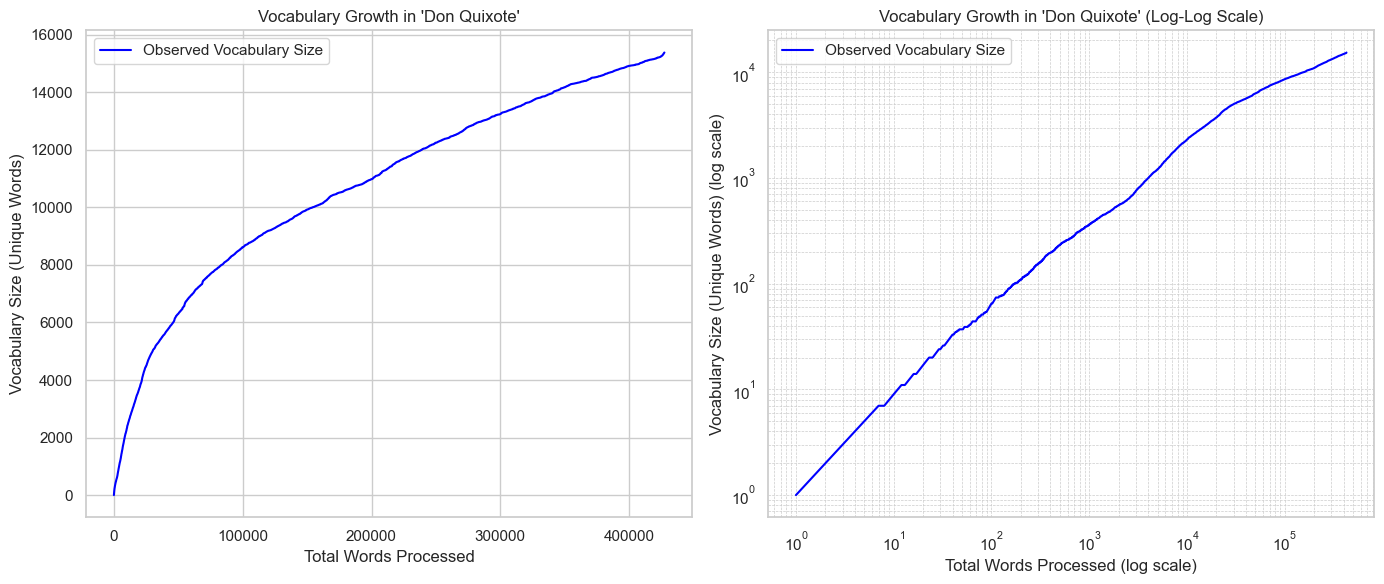

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# First figure: Linear scale
ax[0].plot(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue")
ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title("Vocabulary Growth in 'Don Quixote'")
ax[0].legend()

# Axis 2: Log-Log Scale
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].loglog(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue")
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title("Vocabulary Growth in 'Don Quixote' (Log-Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/heaps-quijote-raw.png", dpi=300)
plt.show()

We'll try to fit two models to the data:

#### A linear model over the logarithms of the two variables

Provided that
$$
    V(n) \propto n^{\beta} \Longrightarrow V(n) = K n^{\beta} 
$$
where, trivially, V(0) = 0, then we can take logarithms on both sides to get:
$$
    \log(V(n)) = \log(K) + \beta \log(n)
$$

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(np.log(words_processed).reshape(-1, 1), np.log(vocab_sizes).reshape(-1, 1))
beta_ols = model.coef_[0][0]
K_ols = np.exp(model.intercept_[0])
print(f"Fitted parameters: K = {K_ols:.4f}, beta = {beta_ols:.4f}")

Fitted parameters: K = 23.5100, beta = 0.5050


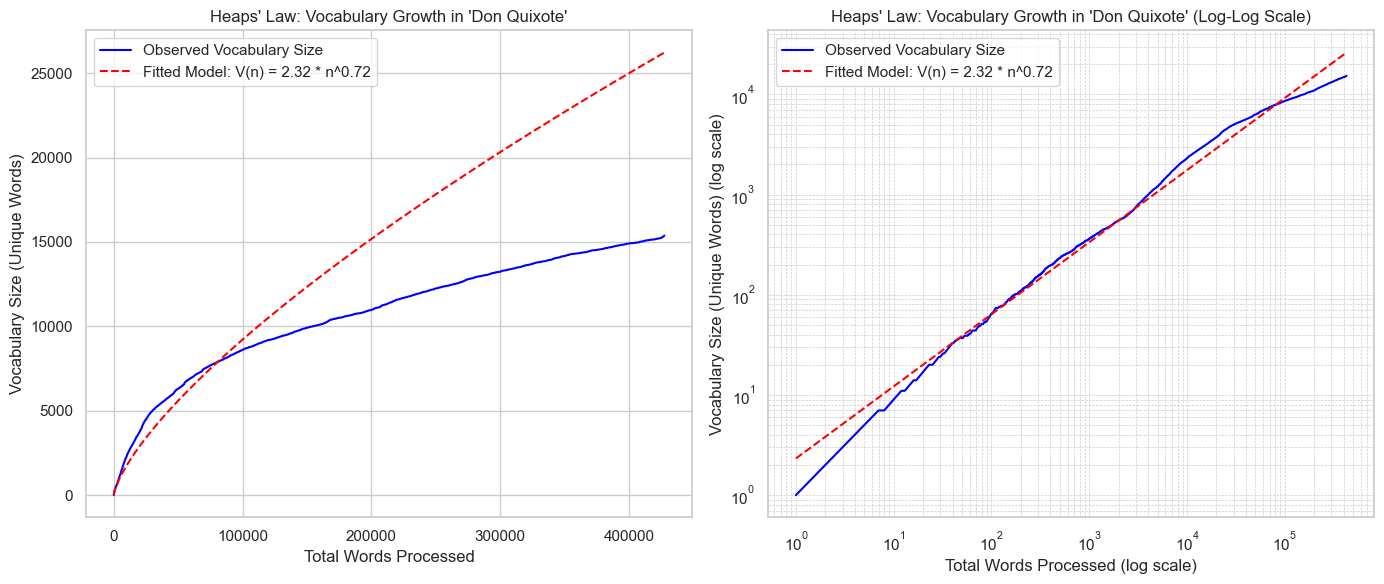

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# First figure: Linear scale
ax[0].plot(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue")
ax[0].plot(
    words_processed,
    K_ols * words_processed**beta_ols,
    label=f"Fitted Model: V(n) = {K_ols:.2f} * n^{beta_ols:.2f}",
    color="red",
    linestyle="--",
)
ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title("Heaps' Law: Vocabulary Growth in 'Don Quixote'")
ax[0].legend()

# Axis 2: Log-Log Scale
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].loglog(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue")
ax[1].loglog(
    words_processed,
    K_ols * words_processed**beta_ols,
    label=f"Fitted Model: V(n) = {K_ols:.2f} * n^{beta_ols:.2f}",
    color="red",
    linestyle="--",
)
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title("Heaps' Law: Vocabulary Growth in 'Don Quixote' (Log-Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/heaps-quijote-ols.png", dpi=300)
plt.show()

#### A power law model

One of the issues with the above model, is that the log-transformation of the variables distorts the error structure of the data, which the ordinary least squares (OLS) method of linear regressions assumes to be normally distributed and homoscedastic (i.e., having constant variance). This transformation converts normally distributed residuals into log-normally distributed ones, thereby rendering linear regression as a modelling approach invalid.

To avoid this problem, we can fit the original power law model directly to the data using non-linear least squares (NLS). This method minimizes the sum of squared differences between the observed values and the values predicted by the model, without transforming the variables. 

This approach still requires both assumptions to be met. The first one (normality of errors) can be assumed to be true thanks to the Central Limit Theorem, given a sufficiently large sample size. The second one (homoscedasticity) should be checked, but not enough data points are available to do so reliably.

An additional bonus of the OLS implementation by `scipy.optimize` is that it makes use of a quasi-Newton method for loss minimisation. As a consequence it calculates an approximation of the inverse Hessian at every iteration, and therefore an approximation to the covariance matrix.

For a minimisation of $\sum(y_i -f(x_i,p))^2$, the covariance matrix returned is based on the local curvature of the loss, which is quantified by the Hessian matrix. SciPy uses the Jacobian to estimate the Hessian, effectively giving a numerical solution to $(J^TJ)^{-1}$ at the optimum point. From the covariance matrix we can take the square root of the diagonal elements (variances) to get the standard deviations, and thereby an error estimate on the parameter values.


In [6]:
from scipy.optimize import curve_fit


def func_power_law(x: float, beta: float, K: float) -> float:
    return K * x**beta


print(f"Starting a fit from the OLS result (K = {K_ols:.4f}, beta = {beta_ols:.4f})")
(beta_curve_fit, K_curve_fit), pcov = curve_fit(func_power_law, words_processed, vocab_sizes, p0=[beta_ols, K_ols])
print(f"Covariance matrix:\n{pcov}")

print(f"Curve fit parameters: K = {K_curve_fit:.4f} ± {pcov[0][0]:.3f}, beta = {beta_curve_fit:.4f} ± {pcov[1][1]:.3f}")

Starting a fit from the OLS result (K = 23.5100, beta = 0.5050)
Covariance matrix:
[[ 3.05664186e-09 -2.42611372e-06]
 [-2.42611372e-06  1.92931316e-03]]
Curve fit parameters: K = 63.8881 ± 0.000, beta = 0.4230 ± 0.002


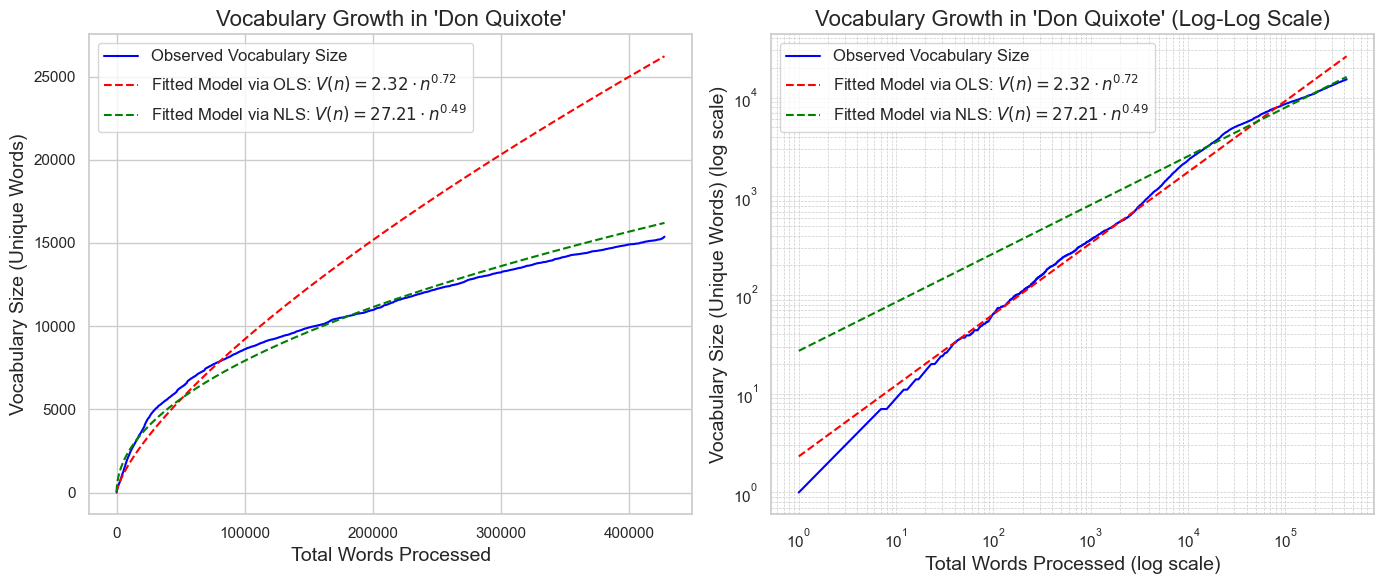

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# First figure: Linear scale
ax[0].plot(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue")
ax[0].plot(
    words_processed,
    K_ols * words_processed**beta_ols,
    label=f"Fitted Model via OLS: $V(n) = {K_ols:.2f} \cdot n^{{{beta_ols:.2f}}}$",
    color="red",
    linestyle="--",
)
ax[0].plot(
    words_processed,
    K_curve_fit * words_processed**beta_curve_fit,
    label=f"Fitted Model via NLS: $V(n) = {K_curve_fit:.2f} \cdot n^{{{beta_curve_fit:.2f}}}$",
    color="green",
    linestyle="--",
)
ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title("Vocabulary Growth in 'Don Quixote'")
ax[0].legend()

# Axis 2: Log-Log Scale
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].loglog(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue")
ax[1].loglog(
    words_processed,
    K_ols * words_processed**beta_ols,
    label=f"Fitted Model via OLS: $V(n) = {K_ols:.2f} \cdot n^{{{beta_ols:.2f}}}$",
    color="red",
    linestyle="--",
)
ax[1].loglog(
    words_processed,
    K_curve_fit * words_processed**beta_curve_fit,
    label=f"Fitted Model via NLS: $V(n) = {K_curve_fit:.2f} \cdot n^{{{beta_curve_fit:.2f}}}$",
    color="green",
    linestyle="--",
)
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title("Vocabulary Growth in 'Don Quixote' (Log-Log Scale)")
ax[1].legend()

for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/heaps-quijote.png", dpi=300)
plt.show()

## Binning
The above models show a clear deviation between the models (both OLS and Curve-fitting) and the data, particularly visible in log-space.
To help circumvent this, the literature suggests a combination of binning and bootstrapping approaches [1, 2].

In [16]:
num_bins = 20
words_processed_bins = np.logspace(1, np.log10(len(words_processed)), num_bins + 1, dtype=np.uint32)
vocab_sizes_binned = np.zeros(num_bins)
for i, (bottom_bin, top_bin) in enumerate(zip(words_processed_bins[:-1], words_processed_bins[1:])):
    vocab_sizes_slice = vocab_sizes[(words_processed >= bottom_bin) & (words_processed < top_bin)]
    if len(vocab_sizes_slice) > 0:
        vocab_sizes_binned[i] = np.mean(vocab_sizes_slice)
    else:
        vocab_sizes_binned[i] = 0
words_processed_binned = (words_processed_bins[:-1] + words_processed_bins[1:]) / 2

In [17]:
model = LinearRegression()

print(f"Starting a linear regression on log-log data...")
model.fit(np.log(words_processed_binned).reshape(-1, 1), np.log(vocab_sizes_binned).reshape(-1, 1))
beta_ols = model.coef_[0][0]
K_ols = np.exp(model.intercept_[0])
print(f"Fitted parameters: K = {K_ols:.4f}, beta = {beta_ols:.4f}")


print(f"Starting a fit from the OLS result (K = {K_ols:.4f}, beta = {beta_ols:.4f})")
(beta_curve_fit, K_curve_fit), pcov = curve_fit(
    func_power_law, words_processed_binned, vocab_sizes_binned, p0=[beta_ols, K_ols]
)
print(f"Covariance matrix:\n{pcov}")

print(f"Curve fit parameters: K = {K_curve_fit:.4f} ± {pcov[0][0]:.3f}, beta = {beta_curve_fit:.4f} ± {pcov[1][1]:.3f}")

Starting a linear regression on log-log data...
Fitted parameters: K = 2.3206, beta = 0.7198
Starting a fit from the OLS result (K = 2.3206, beta = 0.7198)
Covariance matrix:
[[ 3.78569596e-04 -1.23222906e-01]
 [-1.23222906e-01  4.03895794e+01]]
Curve fit parameters: K = 27.2090 ± 0.000, beta = 0.4928 ± 40.390


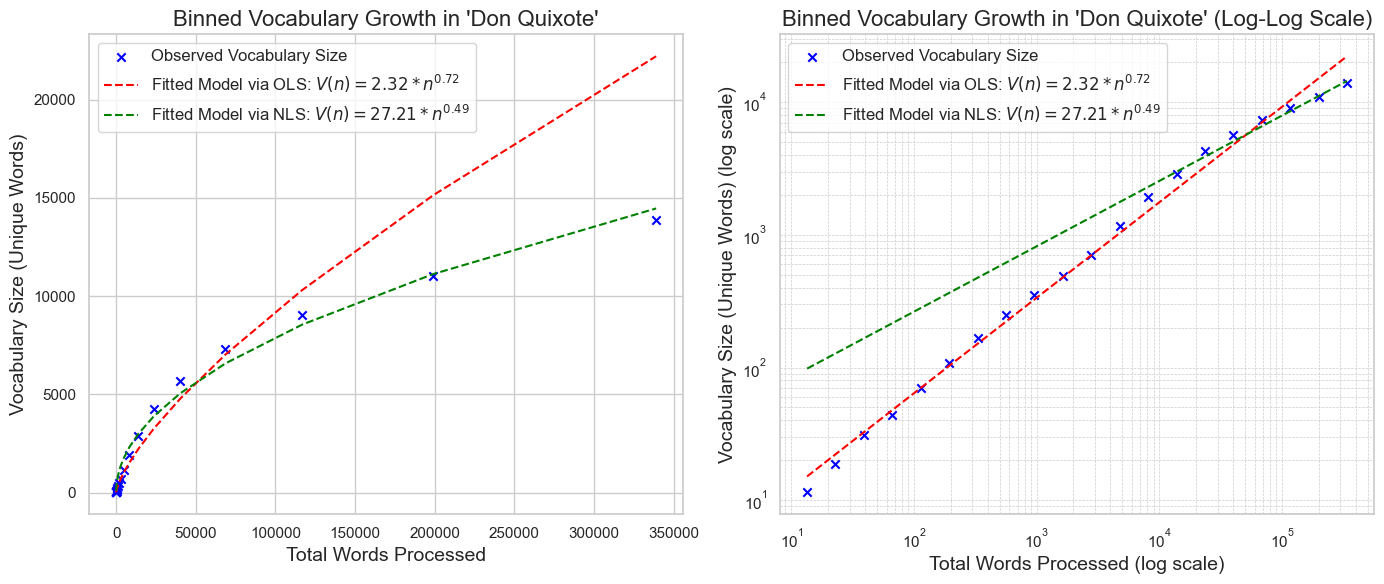

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
X = np.arange(1, len(words) + 1)

# First figure: Linear scale
ax[0].scatter(words_processed_binned, vocab_sizes_binned, label="Observed Vocabulary Size", color="blue", marker="x")
ax[0].plot(
    words_processed_binned,
    K_ols * words_processed_binned**beta_ols,
    label=f"Fitted Model via OLS: $V(n) = {K_ols:.2f} * n^{{{beta_ols:.2f}}}$",
    color="red",
    linestyle="--",
)
ax[0].plot(
    words_processed_binned,
    K_curve_fit * words_processed_binned**beta_curve_fit,
    label=f"Fitted Model via NLS: $V(n) = {K_curve_fit:.2f} * n^{{{beta_curve_fit:.2f}}}$",
    color="green",
    linestyle="--",
)
ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title("Binned Vocabulary Growth in 'Don Quixote'")
ax[0].legend()

# Axis 2: Log-Log Scale
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].scatter(words_processed_binned, vocab_sizes_binned, label="Observed Vocabulary Size", color="blue", marker="x")
ax[1].plot(
    words_processed_binned,
    K_ols * words_processed_binned**beta_ols,
    label=f"Fitted Model via OLS: $V(n) = {K_ols:.2f} * n^{{{beta_ols:.2f}}}$",
    color="red",
    linestyle="--",
)
ax[1].plot(
    words_processed_binned,
    K_curve_fit * words_processed_binned**beta_curve_fit,
    label=f"Fitted Model via NLS: $V(n) = {K_curve_fit:.2f} * n^{{{beta_curve_fit:.2f}}}$",
    color="green",
    linestyle="--",
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title("Binned Vocabulary Growth in 'Don Quixote' (Log-Log Scale)")
ax[1].legend()

for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/heaps-quijote-binned.png", dpi=300)
plt.show()

## Bootstrapping approaches

Now, we'll do a more interesting approach to the same problem. Instead of performing a simple "single run" through the text, we'll randomize the text order several times. This way, we can create multiple "bootstrapped" samples of our data and analyze the variability in the vocabulary growth patterns.

In [34]:
import random

random.seed(42)

num_bootstraps = 10
words_processed = np.empty(len(words) * num_bootstraps, dtype=np.uint32)
vocab_sizes = np.empty(len(words) * num_bootstraps, dtype=np.uint32)
print(f"Preparing {num_bootstraps} bootstrapped samples...")
for i in range(num_bootstraps):
    reordered_words = words.copy()
    random.shuffle(reordered_words)
    words_processed[i * len(words) : (i + 1) * len(words)], vocab_sizes[i * len(words) : (i + 1) * len(words)], _ = (
        analyze_vocabulary_growth(reordered_words)
    )

print(f"Generated {len(words_processed)} observations")

Preparing 10 bootstrapped samples...
Generated 4274130 observations


C:\Users\mirxm\AppData\Local\Temp\ipykernel_38012\626127143.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\mirxm\AppData\Local\Temp\ipykernel_38012\626127143.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("../reports/figures/heaps-quijote-bootstrapped-raw.png", dpi=300)
c:\Users\mirxm\Storage\Work\MDS\S3\IRRS\MDS-IRRS-ZipfLaw\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


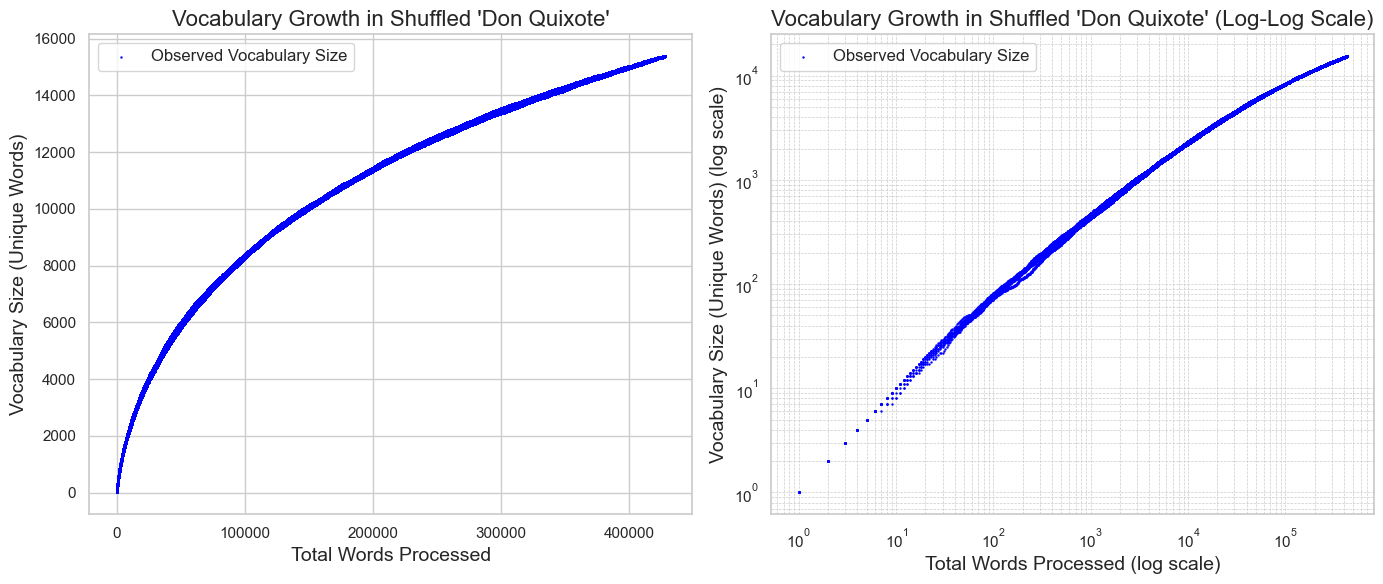

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# First figure: Linear scale
ax[0].scatter(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue", s=0.5)
ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title("Vocabulary Growth in Shuffled 'Don Quixote'")
ax[0].legend()

# Axis 2: Log-Log Scale
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].scatter(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue", s=0.5)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title("Vocabulary Growth in Shuffled 'Don Quixote' (Log-Log Scale)")
ax[1].legend()

for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/heaps-quijote-bootstrapped-raw.png", dpi=300)
plt.show()

In [37]:
model = LinearRegression()

print(f"Starting a linear regression on log-log data...")
model.fit(np.log(words_processed).reshape(-1, 1), np.log(vocab_sizes).reshape(-1, 1))
beta_ols = model.coef_[0][0]
K_ols = np.exp(model.intercept_[0])
print(f"Fitted parameters: K = {K_ols:.4f}, beta = {beta_ols:.4f}")

print(f"Starting a fit from the OLS result (K = {K_ols:.4f}, beta = {beta_ols:.4f})")
(beta_curve_fit, K_curve_fit), pcov = curve_fit(func_power_law, words_processed, vocab_sizes, p0=[beta_ols, K_ols])
print(f"Covariance matrix:\n{pcov}")

print(f"Curve fit parameters: K = {K_curve_fit:.4f} ± {pcov[0][0]:.3f}, beta = {beta_curve_fit:.4f} ± {pcov[1][1]:.3f}")

Starting a linear regression on log-log data...
Fitted parameters: K = 21.1946, beta = 0.5136
Starting a fit from the OLS result (K = 21.1946, beta = 0.5136)
Covariance matrix:
[[ 3.29972642e-10 -2.00886698e-07]
 [-2.00886698e-07  1.22520759e-04]]
Curve fit parameters: K = 48.9525 ± 0.000, beta = 0.4451 ± 0.000


C:\Users\mirxm\AppData\Local\Temp\ipykernel_38012\2353971753.py:54: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\mirxm\AppData\Local\Temp\ipykernel_38012\2353971753.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("../reports/figures/heaps-quijote-bootstrapped.png", dpi=300)
c:\Users\mirxm\Storage\Work\MDS\S3\IRRS\MDS-IRRS-ZipfLaw\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


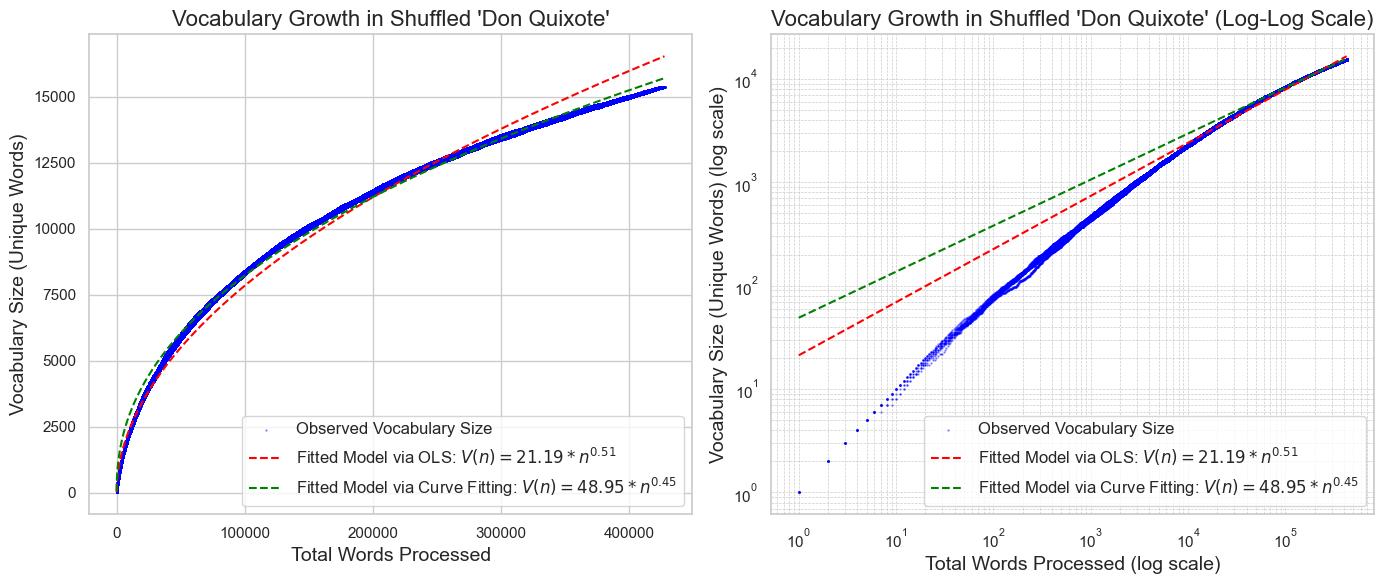

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
X = np.arange(1, len(words) + 1)

# First figure: Linear scale
ax[0].scatter(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue", s=0.5, alpha=0.4)
ax[0].plot(
    X,
    K_ols * X**beta_ols,
    label=f"Fitted Model via OLS: $V(n) = {K_ols:.2f} * n^{{{beta_ols:.2f}}}$",
    color="red",
    linestyle="--",
)
ax[0].plot(
    X,
    K_curve_fit * X**beta_curve_fit,
    label=f"Fitted Model via Curve Fitting: $V(n) = {K_curve_fit:.2f} * n^{{{beta_curve_fit:.2f}}}$",
    color="green",
    linestyle="--",
)
ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title("Vocabulary Growth in Shuffled 'Don Quixote'")
ax[0].legend()

# Axis 2: Log-Log Scale
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].scatter(words_processed, vocab_sizes, label="Observed Vocabulary Size", color="blue", s=0.5, alpha=0.4)
ax[1].plot(
    X,
    K_ols * X**beta_ols,
    label=f"Fitted Model via OLS: $V(n) = {K_ols:.2f} * n^{{{beta_ols:.2f}}}$",
    color="red",
    linestyle="--",
)
ax[1].plot(
    X,
    K_curve_fit * X**beta_curve_fit,
    label=f"Fitted Model via Curve Fitting: $V(n) = {K_curve_fit:.2f} * n^{{{beta_curve_fit:.2f}}}$",
    color="green",
    linestyle="--",
)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title("Vocabulary Growth in Shuffled 'Don Quixote' (Log-Log Scale)")
ax[1].legend()

for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/heaps-quijote-bootstrapped.png", dpi=300)
plt.show()

References:

[1] Lin, Qianying, and Mitchell Newberry. "Seeing through noise in power laws." Journal of the Royal Society Interface 20.205 (2023): 20230310.

[2] Goldstein, Michel L., Steven A. Morris, and Gary G. Yen. "Problems with fitting to the power-law distribution." The European Physical Journal B-Condensed Matter and Complex Systems 41.2 (2004): 255-258.